# **Notebook para tratamento e remoção de dados**


In [2]:
import pandas as pd

In [3]:
dados = pd.read_excel("C:\\Users\\daiki\\OneDrive\\Documentos\\USP\\7 semestre\\CEA\\notebook\\CEA-1\\sipnibancofinal.xls")
linhas, colunas = dados.shape
print("Dados:", linhas, "linhas e", colunas, "colunas")

Dados: 1083 linhas e 61 colunas


In [4]:
columns_para_remover = ['dt_not', 'preench','codigo_ibge', 'mun_not', 'uf_nasc', 'cod_mn', 'mun_nasc', 
                        'idade_txt', 'aleit', 'cod_resid_ibge', 'mun_res', 'uf_resid', 'dt_apl', 
                        'lote', 'dose', 'via_adm', 'local_aplic', 'esavi_noti', 'man_loc', 'man_sis', 'tp_atd', 'diag', 'diag_enc', 'justif','diag_en','cond_en','cls_en', 'enc_fed', 'cls_eifed',
                          'cls_oefed', 'cond_fd', 'cond_oefed', 'diag_compl', ]  # <-- Change these to the actual column names
dados_filtrado = dados.drop(columns=columns_para_remover)

print(f"Restante de colunas: {dados.columns.tolist()}")
print(f"Shape: {dados.shape}")

Restante de colunas: ['dt_not', 'preench', 'codigo_ibge', 'mun_not', 'uf_not', 'pais_nasc', 'uf_nasc', 'cod_mn', 'mun_nasc', 'idade_txt', 'sexo', 'cor', 'gestante', 'aleit', 'cod_resid_ibge', 'mun_res', 'uf_resid', 'cod_prod', 'produto', 'dt_apl', 'lab', 'lote', 'dose', 'via_adm', 'local_aplic', 'tp_med', 'esavi_noti', 'cls_not', 'cls_ei', 'cls_erro', 'evol_caso', 'man_loc', 'man_sis', 'man_out', 'tp_atd', 'diag', 'diag_enc', 'cls_fin', 'cls_eien', 'cls_fei', 'cond_ei', 'cond_oe', 'justif', 'diag_en', 'cond_en', 'cls_en', 'dt_fed', 'enc_fed', 'cls_fed', 'cls_eifed', 'cls_oefed', 'cond_fd', 'cond_oefed', 'diad_enfed', 'cond_enfed', 'cls_enfed', 'diag_compl', 'cls_compl', 'idade_anos', 'tp_ev', 'evol_num']
Shape: (1083, 61)


In [4]:
print("=" * 80)
print("Valores de contagem para todass as colunas")
print("=" * 80)

for col in dados_filtrado.columns:
    print(f"\n Column: '{col}'")
    print("-" * 80)
    
    value_counts = dados_filtrado[col].value_counts(dropna=False).sort_values(ascending=False)
    
    for val, count in value_counts.items():
        percentage = (count / len(dados_filtrado)) * 100
        print(f"  {str(val):<30} {count:>6}  ({percentage:>5.2f}%)")
    
    print()

print("=" * 80)

Valores de contagem para todass as colunas

 Column: 'uf_not'
--------------------------------------------------------------------------------
  SP                                313  (28.90%)
  MG                                186  (17.17%)
  PR                                147  (13.57%)
  SC                                 94  ( 8.68%)
  RS                                 67  ( 6.19%)
  RJ                                 59  ( 5.45%)
  BA                                 57  ( 5.26%)
  ES                                 34  ( 3.14%)
  GO                                 28  ( 2.59%)
  CE                                 21  ( 1.94%)
  AC                                 19  ( 1.75%)
  AL                                  7  ( 0.65%)
  DF                                  7  ( 0.65%)
  AM                                  7  ( 0.65%)
  MT                                  6  ( 0.55%)
  MS                                  5  ( 0.46%)
  RR                                  5  ( 0.46%)
  TO   

---
### **Tratamento das variáveis explicativas**
---

In [28]:
colunas = ['uf_not', 'pais_nasc', 'sexo', 'cor', 
                   'gestante', 'tp_med', 'cls_ei', 'evol_caso', 'cls_eien', 'cls_fei', 'cond_ei', 'dt_fed', 'cls_fed', 'diad_enfed', 'cond_enfed', 'cls_enfed', 'idade_anos', 'evol_num']

dados_selecionado = dados[colunas]
print(dados_selecionado.columns.tolist())

['uf_not', 'pais_nasc', 'sexo', 'cor', 'gestante', 'tp_med', 'cls_ei', 'evol_caso', 'cls_eien', 'cls_fei', 'cond_ei', 'dt_fed', 'cls_fed', 'diad_enfed', 'cond_enfed', 'cls_enfed', 'idade_anos', 'evol_num']


#### **Análise individual e observando dependências**

1. UF_NOT -> Criando nova variável "regiao"


SP: 313  |  MG: 186  |  PR: 147  |  SC: 94  |  RS: 67  |  RJ: 59  |  BA: 57  |  ES: 34  |  GO: 28  |  CE: 21  |  AC: 19  |  AL: 7  |  DF: 7  |  AM: 7  |  MT: 6  |  MS: 5  |  RR: 5  |  TO: 5  |  PB: 4  |  MA: 3  |  RN: 3  |  PA: 2  |  RO: 1  |  AP: 1  |  SE: 1  |  PE: 1  |  



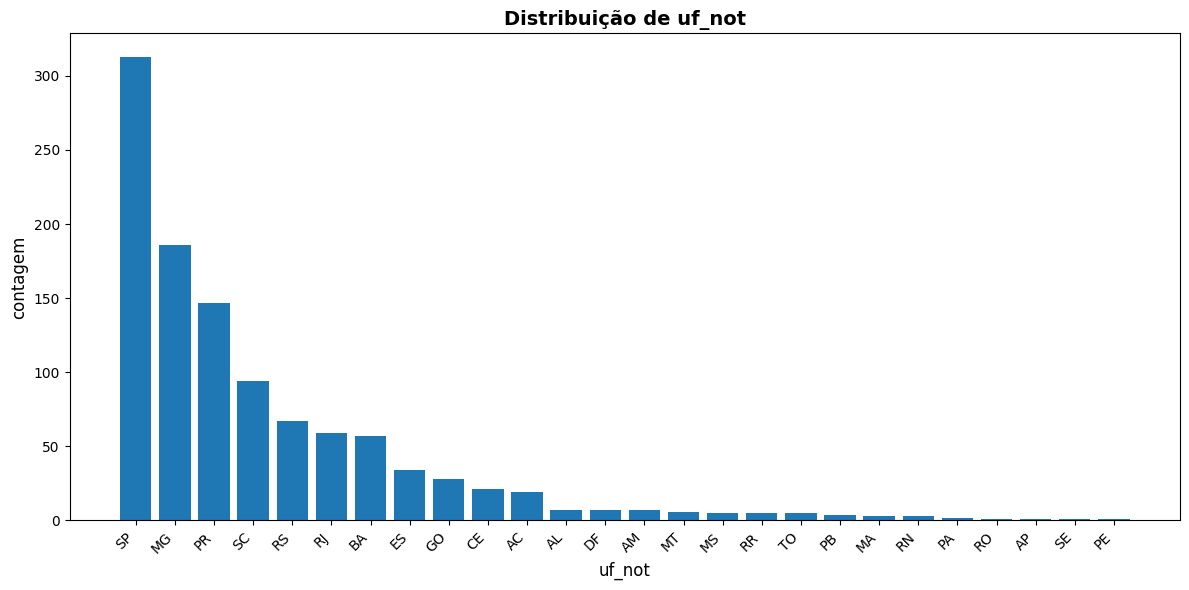

In [14]:
import matplotlib.pyplot as plt

uf_counts = dados['uf_not'].value_counts().sort_values(ascending=False)

print("\n" + "="*280)
for regiao, count in uf_counts.items():
    print(f"{regiao}: {count}", end="  |  ")
print("\n" + "="*280 + "\n")

plt.figure(figsize=(12, 6))
plt.bar(range(len(uf_counts)), uf_counts.values)
plt.xlabel('uf_not', fontsize=12)
plt.ylabel('contagem', fontsize=12)
plt.title('Distribuição de uf_not', fontsize=14, fontweight='bold')
plt.xticks(range(len(uf_counts)), uf_counts.index, rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
# Mapeamento de UF para região geográfica
mapa_regiao = {
    # Norte
    'AC': 'Norte', 'AM': 'Norte', 'AP': 'Norte', 'PA': 'Norte', 'RO': 'Norte', 'RR': 'Norte', 'TO': 'Norte',
    # Nordeste
    'AL': 'Nordeste', 'BA': 'Nordeste', 'CE': 'Nordeste', 'MA': 'Nordeste', 'PB': 'Nordeste', 'PE': 'Nordeste', 'RN': 'Nordeste', 'SE': 'Nordeste',
    # Centro-Oeste
    'DF': 'Centro-Oeste', 'GO': 'Centro-Oeste', 'MS': 'Centro-Oeste', 'MT': 'Centro-Oeste',
    # Sudeste
    'ES': 'Sudeste', 'MG': 'Sudeste', 'RJ': 'Sudeste', 'SP': 'Sudeste',
    # Sul
    'PR': 'Sul', 'RS': 'Sul', 'SC': 'Sul'
}

# Criar coluna 'regiao' baseada em 'uf_not'
dados['regiao'] = dados['uf_not'].map(mapa_regiao)

print("\nDistribuição por Região:")
print(dados['regiao'].value_counts().sort_values(ascending=False))


Mapeamento de UF para Região criado com sucesso!

Distribuição por Região:
regiao
Sudeste         592
Sul             308
Nordeste         97
Centro-Oeste     46
Norte            40
Name: count, dtype: int64



Sudeste: 592  |  Sul: 308  |  Nordeste: 97  |  Centro-Oeste: 46  |  Norte: 40  |  



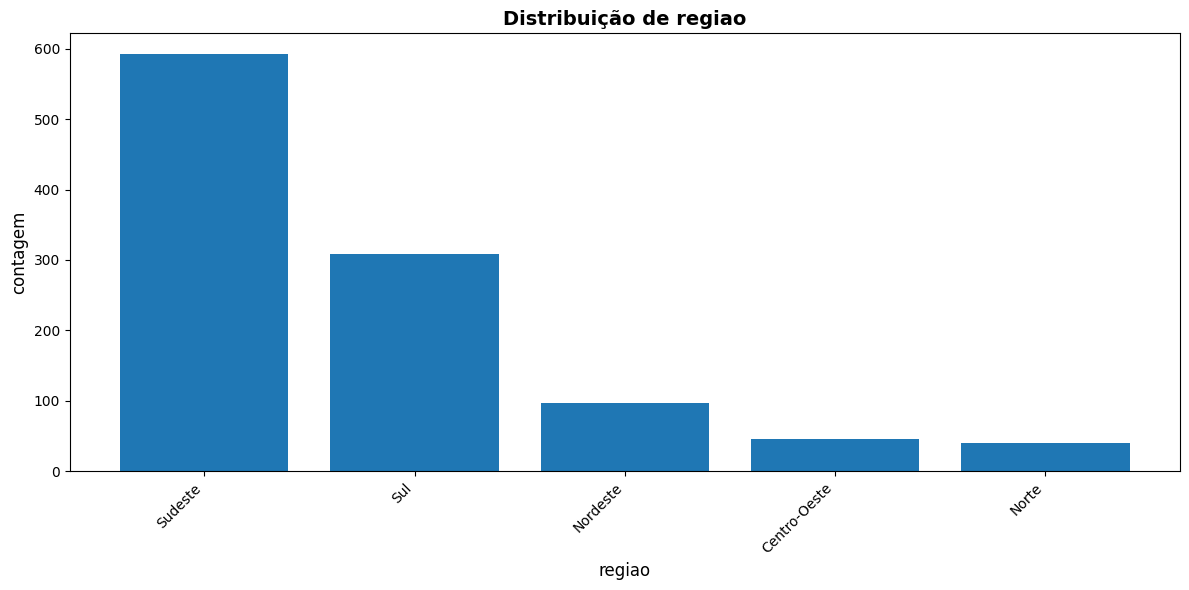

In [10]:
import matplotlib.pyplot as plt

uf_counts = dados['regiao'].value_counts().sort_values(ascending=False)

print("\n" + "="*80)
for regiao, count in uf_counts.items():
    print(f"{regiao}: {count}", end="  |  ")
print("\n" + "="*80 + "\n")

plt.figure(figsize=(12, 6))
plt.bar(range(len(uf_counts)), uf_counts.values)
plt.xlabel('regiao', fontsize=12)
plt.ylabel('contagem', fontsize=12)
plt.title('Distribuição de regiao', fontsize=14, fontweight='bold')
plt.xticks(range(len(uf_counts)), uf_counts.index, rotation=45, ha='right')
plt.tight_layout()
plt.show()


2. PAIS_NASC

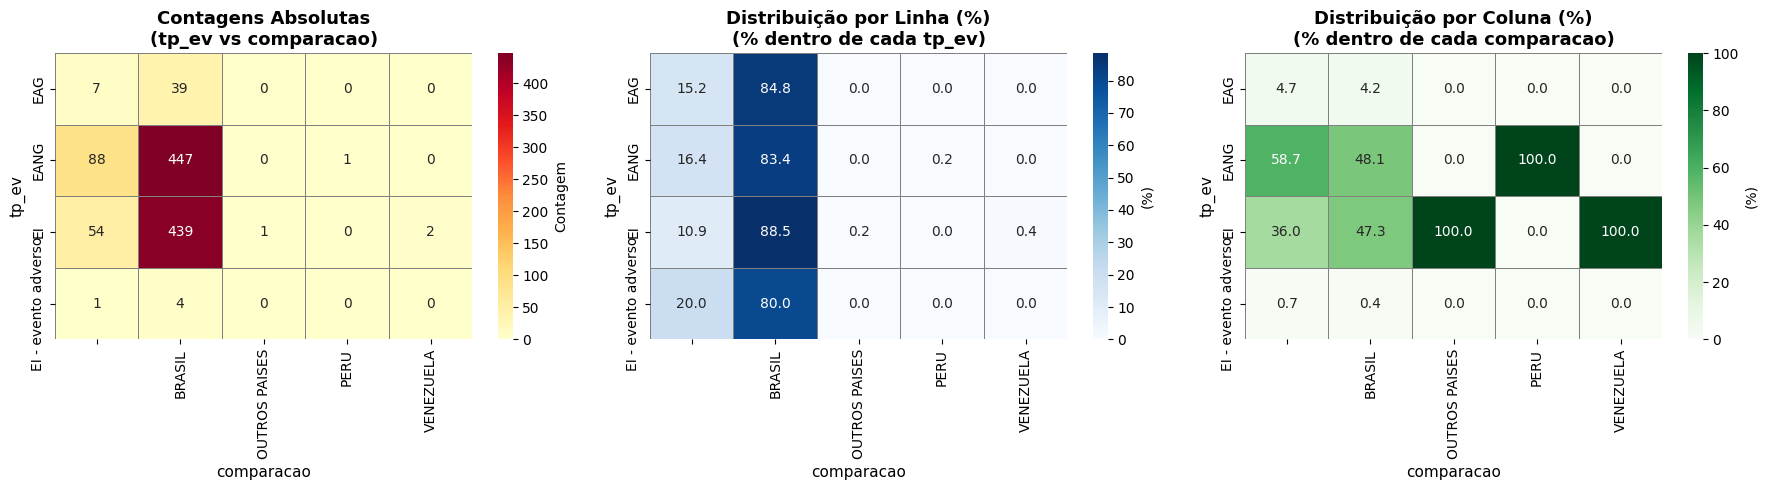

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

comparacao = 'pais_nasc'

dados_resposta = dados[['tp_ev', comparacao]]

contagem = pd.crosstab(dados_resposta['tp_ev'], dados_resposta[comparacao])
percentual_linhas = pd.crosstab(dados_resposta['tp_ev'], dados_resposta[comparacao], normalize='index') * 100
percentual_colunas = pd.crosstab(dados_resposta['tp_ev'], dados_resposta[comparacao], normalize='columns') * 100

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(contagem, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'Contagem'},
            ax=axes[0], linewidths=0.5, linecolor='gray')
axes[0].set_title('Contagens Absolutas\n(tp_ev vs comparacao)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('comparacao', fontsize=11)
axes[0].set_ylabel('tp_ev', fontsize=11)

sns.heatmap(percentual_linhas, annot=True, fmt='.1f', cmap='Blues', cbar_kws={'label': '(%)'},
            ax=axes[1], linewidths=0.5, linecolor='gray')
axes[1].set_title('Distribuição por Linha (%)\n(% dentro de cada tp_ev)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('comparacao', fontsize=11)
axes[1].set_ylabel('tp_ev', fontsize=11)

sns.heatmap(percentual_colunas, annot=True, fmt='.1f', cmap='Greens', cbar_kws={'label': '(%)'},
            ax=axes[2], linewidths=0.5, linecolor='gray')
axes[2].set_title('Distribuição por Coluna (%)\n(% dentro de cada comparacao)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('comparacao', fontsize=11)
axes[2].set_ylabel('tp_ev', fontsize=11)

plt.tight_layout()
plt.show()

---
### **Tratamento das variáveis respostas**
---

In [6]:
dados['tp_ev'] = dados['tp_ev'].replace(
    'Não Grave (EANG) - Qualquer outro evento que não esteja incluído nos critéri',
    'EANG'
).replace('Erro de imunização com evento adverso', 'EI - evento adverso').replace('Erro de Imunização', 'EI').replace('Grave (EAG)', 'EAG')

dados['cls_fin'] = dados['cls_fin'].replace('Não Grave (EANG)','EANG').replace('Erro de Imunização - Com evento adverso', 'EI - evento adverso').replace('Erro de Imunização', 'EI').replace('Grave (EAG)', 'EAG')

print("Valores da variavel tp_ev:", dados['tp_ev'].unique())

print("Valores da variavel cls_fin:", dados['cls_fin'].unique())

Valores da variavel tp_ev: ['EANG' 'EI' 'EI - evento adverso' 'EAG']
Valores da variavel cls_fin: [' ' 'EI' 'EANG' 'EAG' 'Inclassificável' 'EI - evento adverso']


cls_fin
EI                     391
EANG                   374
                       277
EAG                     32
Inclassificável          8
EI - evento adverso      1
Name: count, dtype: int64


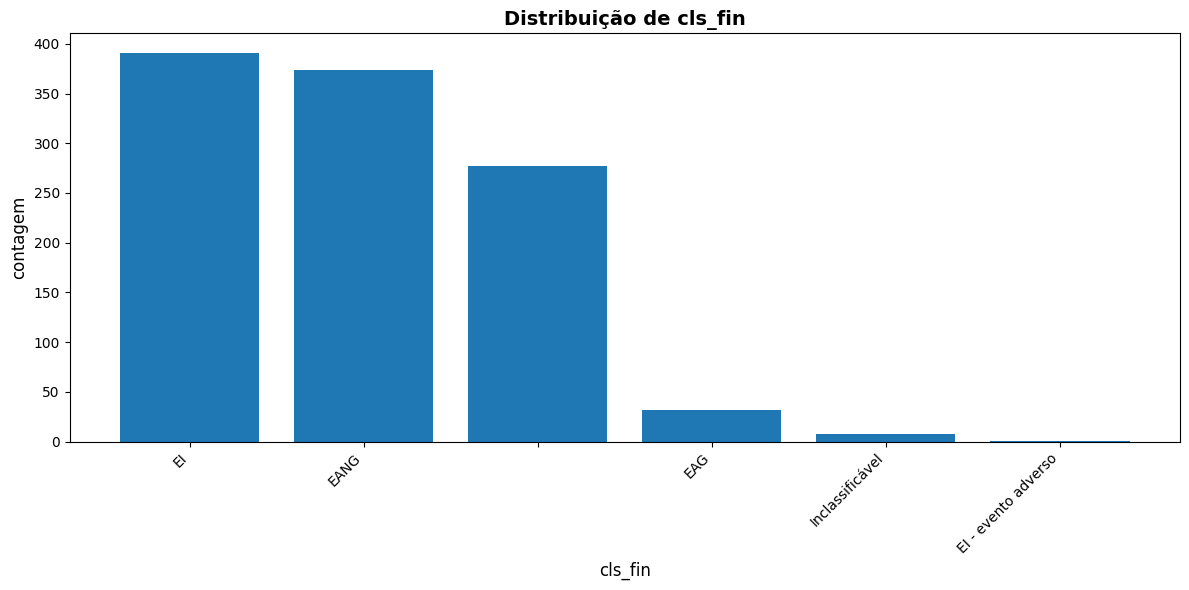

In [22]:
import matplotlib.pyplot as plt

uf_counts = dados['cls_fin'].value_counts().sort_values(ascending=False)

print(uf_counts)

plt.figure(figsize=(12, 6))
plt.bar(range(len(uf_counts)), uf_counts.values)
plt.xlabel('cls_fin', fontsize=12)
plt.ylabel('contagem', fontsize=12)
plt.title('Distribuição de cls_fin', fontsize=14, fontweight='bold')
plt.xticks(range(len(uf_counts)), uf_counts.index, rotation=45, ha='right')
plt.tight_layout()
plt.show()



tp_ev
EANG                   536
EI                     496
EAG                     46
EI - evento adverso      5
Name: count, dtype: int64


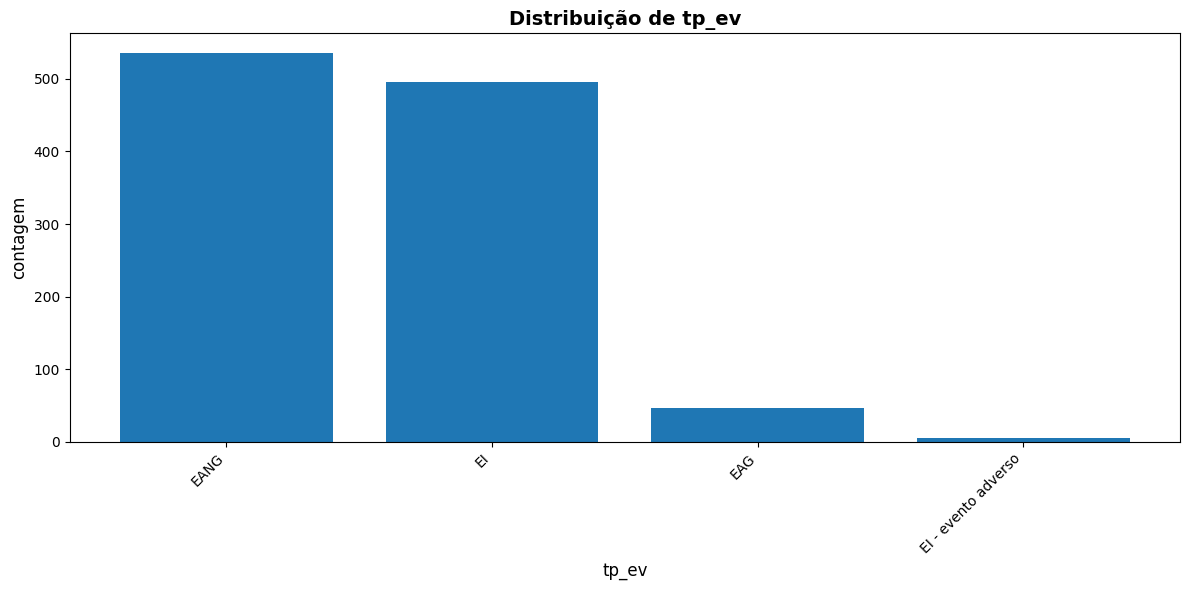

In [23]:
import matplotlib.pyplot as plt

uf_counts = dados['tp_ev'].value_counts().sort_values(ascending=False)


print(uf_counts)
plt.figure(figsize=(12, 6))
plt.bar(range(len(uf_counts)), uf_counts.values)
plt.xlabel('tp_ev', fontsize=12)
plt.ylabel('contagem', fontsize=12)
plt.title('Distribuição de tp_ev', fontsize=14, fontweight='bold')
plt.xticks(range(len(uf_counts)), uf_counts.index, rotation=45, ha='right')
plt.tight_layout()
plt.show()

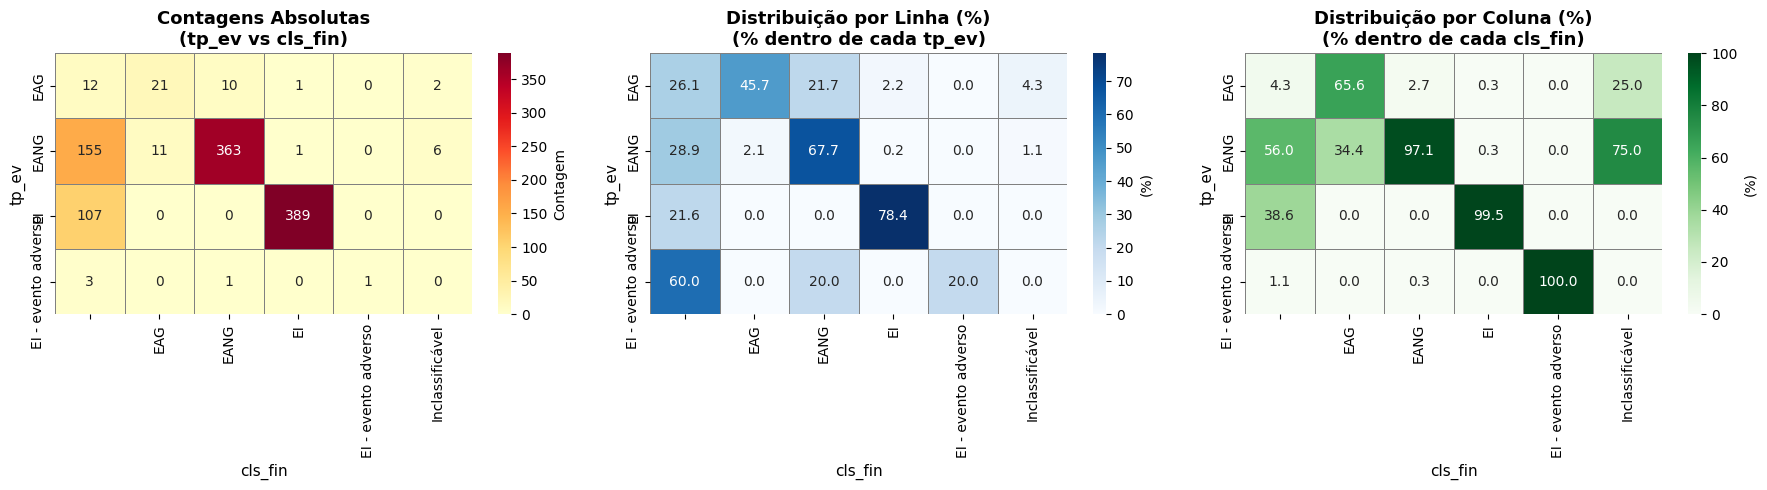

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

dados_resposta = dados[['tp_ev', 'cls_fin']]

contagem = pd.crosstab(dados_resposta['tp_ev'], dados_resposta['cls_fin'])
percentual_linhas = pd.crosstab(dados_resposta['tp_ev'], dados_resposta['cls_fin'], normalize='index') * 100
percentual_colunas = pd.crosstab(dados_resposta['tp_ev'], dados_resposta['cls_fin'], normalize='columns') * 100

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(contagem, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'Contagem'},
            ax=axes[0], linewidths=0.5, linecolor='gray')
axes[0].set_title('Contagens Absolutas\n(tp_ev vs cls_fin)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('cls_fin', fontsize=11)
axes[0].set_ylabel('tp_ev', fontsize=11)

sns.heatmap(percentual_linhas, annot=True, fmt='.1f', cmap='Blues', cbar_kws={'label': '(%)'},
            ax=axes[1], linewidths=0.5, linecolor='gray')
axes[1].set_title('Distribuição por Linha (%)\n(% dentro de cada tp_ev)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('cls_fin', fontsize=11)
axes[1].set_ylabel('tp_ev', fontsize=11)

sns.heatmap(percentual_colunas, annot=True, fmt='.1f', cmap='Greens', cbar_kws={'label': '(%)'},
            ax=axes[2], linewidths=0.5, linecolor='gray')
axes[2].set_title('Distribuição por Coluna (%)\n(% dentro de cada cls_fin)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('cls_fin', fontsize=11)
axes[2].set_ylabel('tp_ev', fontsize=11)

plt.tight_layout()
plt.show()